# CASALS L1B H5 schema and georeferencing audit

This notebook is designed to answer one specific question:

**Does the CASALS L1B H5 file contain enough information to georeference waveform-decomposed non-reference peaks, or does it only provide geolocation for one reference return per pulse?**

The notebook does not assume the current project scripts are complete. It recursively scans the entire H5 file, including all groups, datasets, shapes, dtypes, and attributes. It then searches for:

1. waveform arrays;
2. pulse indexing arrays;
3. reference-return geolocation fields;
4. per-bin geolocation fields;
5. multi-return / multi-peak geolocation fields;
6. sensor/platform/attitude/scan-angle fields that could theoretically allow georeferencing after waveform decomposition.

A conservative conclusion is generated at the end.


In [1]:
from pathlib import Path
import re
import json
import math
import warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
warnings.filterwarnings("ignore", category=RuntimeWarning)


## 1. User parameters

Set `H5_FILES` explicitly. You can pass one file or a list of files. The notebook will analyze each file independently and then provide a combined summary.

No argparse is used.


In [2]:
# ---------------------------------------------------------------------
# User parameters
# ---------------------------------------------------------------------

H5_FILES = [
    # Example:
    # r"D:/CASALS/casals_l1b_20241112T165718_001_02.h5",
    "../casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5"
]

# Optional: if H5_FILES is empty, search these glob patterns.
H5_GLOBS = [
    r"./*.h5",
    r"./*.hdf5",
    r"./**/*.h5",
    r"./**/*.hdf5",
]

# Safety controls for large H5 files.
MAX_ATTR_VALUE_CHARS = 240
MAX_DATASET_SAMPLE_VALUES = 2000
MAX_DISPLAY_DATASETS = 300

# For waveform visualization.
N_WAVEFORM_EXAMPLES = 6
RANDOM_SEED = 42

# If True, write CSV summaries next to the notebook.
WRITE_CSV_OUTPUTS = True
OUTPUT_DIR = Path("./casals_h5_schema_audit_outputs")


In [3]:
def resolve_h5_files(h5_files, h5_globs):
    paths = []
    for p in h5_files:
        p = Path(p).expanduser()
        if p.exists():
            paths.append(p.resolve())
        else:
            print(f"[WARN] H5 file does not exist: {p}")

    if not paths:
        seen = set()
        for pat in h5_globs:
            for p in Path(".").glob(pat):
                if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
                    rp = p.resolve()
                    if rp not in seen:
                        paths.append(rp)
                        seen.add(rp)

    if not paths:
        raise FileNotFoundError("No H5/HDF5 files found. Please set H5_FILES explicitly.")

    return paths

h5_paths = resolve_h5_files(H5_FILES, H5_GLOBS)
display(pd.DataFrame({"h5_file": [str(p) for p in h5_paths]}))


,h5_file
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5


## 2. H5 recursive inventory

This section lists every dataset and group in the file. It records:

- full H5 path;
- object type;
- shape;
- number of dimensions;
- dtype;
- size;
- chunking/compression;
- attributes;
- simple keyword-based role hints.

This is the main check against the possibility that relevant geolocation arrays exist but were missed by earlier project scripts.


In [4]:
def safe_attr_value(v, max_chars=MAX_ATTR_VALUE_CHARS):
    try:
        if isinstance(v, bytes):
            s = v.decode("utf-8", errors="replace")
        elif isinstance(v, np.ndarray):
            if v.size <= 12:
                s = np.array2string(v, threshold=12)
            else:
                s = f"ndarray shape={v.shape}, dtype={v.dtype}, first={v.flat[0]!r}"
        else:
            s = repr(v)
    except Exception as exc:
        s = f"<unreadable attr: {exc}>"
    if len(s) > max_chars:
        s = s[:max_chars] + "..."
    return s

def attrs_to_short_json(obj):
    if not hasattr(obj, "attrs") or len(obj.attrs) == 0:
        return ""
    d = {}
    for k, v in obj.attrs.items():
        d[str(k)] = safe_attr_value(v)
    return json.dumps(d, ensure_ascii=False)

def normalize_shape(shape):
    if shape is None:
        return tuple()
    return tuple(int(x) for x in shape)

ROLE_PATTERNS = {
    "waveform": r"(waveform|rx|tx|return_wave|receive)",
    "longitude": r"(longitude|lon|lng)",
    "latitude": r"(latitude|lat)",
    "height_z": r"(^z$|[_/]z$|height|elevation|elev|altitude|alt|refh|range)",
    "reference_return": r"(refh|reference|ref[_-]?return|max[_-]?rx|maxbin|max_bin)",
    "amplitude_snr": r"(amp|amplitude|snr|signal|intensity|power|energy)",
    "background_threshold": r"(background|bg_|noise|std|mean|threshold|thres)",
    "quality_error": r"(error|sigma|uncert|quality|good|flag|mask|valid)",
    "pulse_index": r"(pulse|shot|record|index|idx)",
    "sweep_track": r"(sweep|track|scan|frame|line)",
    "time": r"(time|delta_time|gps|utc|tai)",
    "platform_position": r"(platform|aircraft|sensor|position|pos|ecef|x_|y_|z_|nav)",
    "attitude_angle": r"(roll|pitch|yaw|heading|attitude|quat|quaternion|azimuth|zenith|angle|look|boresight)",
    "return_peak": r"(return|peak|echo|gaussian|component)",
    "classification": r"(class|classification|label)"
}

def infer_roles(path, attrs_json=""):
    text = f"{path} {attrs_json}".lower()
    roles = []
    for role, pat in ROLE_PATTERNS.items():
        if re.search(pat, text):
            roles.append(role)
    return ",".join(roles)

def h5_inventory_one(h5_path):
    records = []
    with h5py.File(h5_path, "r") as f:
        # root attrs
        records.append({
            "h5_file": str(h5_path),
            "path": "/",
            "name": "/",
            "object_type": "group",
            "shape": "",
            "ndim": np.nan,
            "dtype": "",
            "size": np.nan,
            "chunks": "",
            "compression": "",
            "attrs": attrs_to_short_json(f),
            "roles": infer_roles("/", attrs_to_short_json(f)),
        })

        def visitor(name, obj):
            full_path = "/" + name
            attrs = attrs_to_short_json(obj)
            if isinstance(obj, h5py.Dataset):
                shape = normalize_shape(obj.shape)
                rec = {
                    "h5_file": str(h5_path),
                    "path": full_path,
                    "name": Path(full_path).name,
                    "object_type": "dataset",
                    "shape": str(shape),
                    "shape_tuple": shape,
                    "ndim": len(shape),
                    "dtype": str(obj.dtype),
                    "size": int(np.prod(shape)) if len(shape) else int(obj.size),
                    "chunks": str(obj.chunks) if obj.chunks is not None else "",
                    "compression": str(obj.compression) if obj.compression is not None else "",
                    "attrs": attrs,
                    "roles": infer_roles(full_path, attrs),
                }
            elif isinstance(obj, h5py.Group):
                rec = {
                    "h5_file": str(h5_path),
                    "path": full_path,
                    "name": Path(full_path).name,
                    "object_type": "group",
                    "shape": "",
                    "shape_tuple": tuple(),
                    "ndim": np.nan,
                    "dtype": "",
                    "size": np.nan,
                    "chunks": "",
                    "compression": "",
                    "attrs": attrs,
                    "roles": infer_roles(full_path, attrs),
                }
            else:
                rec = {
                    "h5_file": str(h5_path),
                    "path": full_path,
                    "name": Path(full_path).name,
                    "object_type": type(obj).__name__,
                    "shape": "",
                    "shape_tuple": tuple(),
                    "ndim": np.nan,
                    "dtype": "",
                    "size": np.nan,
                    "chunks": "",
                    "compression": "",
                    "attrs": attrs,
                    "roles": infer_roles(full_path, attrs),
                }
            records.append(rec)

        f.visititems(visitor)

    df = pd.DataFrame(records)
    if "shape_tuple" not in df.columns:
        df["shape_tuple"] = [tuple() for _ in range(len(df))]
    return df

inventory_list = []
for h5_path in h5_paths:
    inv = h5_inventory_one(h5_path)
    inventory_list.append(inv)

inventory_df = pd.concat(inventory_list, ignore_index=True)
dataset_df = inventory_df[inventory_df["object_type"] == "dataset"].copy()

print(f"Total H5 objects: {len(inventory_df)}")
print(f"Total datasets: {len(dataset_df)}")
display(dataset_df[["h5_file", "path", "shape", "ndim", "dtype", "size", "chunks", "compression", "roles", "attrs"]].head(MAX_DISPLAY_DATASETS))


Total H5 objects: 69
Total datasets: 68


,h5_file,path,shape,ndim,dtype,size,chunks,compression,roles,attrs
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/bg_mean,"(3604480,)",1.0,float64,3604480.0,"(7040,)",gzip,"reference_return,background_threshold","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/bg_std,"(3604480,)",1.0,float64,3604480.0,"(7040,)",gzip,"reference_return,background_threshold","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/bin_size,"(3604480,)",1.0,float64,3604480.0,"(7040,)",gzip,reference_return,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/dac,"(3604480,)",1.0,float64,3604480.0,"(7040,)",gzip,reference_return,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/delta_time,"(3604480,)",1.0,float64,3604480.0,"(7040,)",gzip,"reference_return,time,classification","{""CLASS"": ""DIMENSION_SCALE"", ""NAME"": """", ""REFERENCE_LIST"": ""ndarray shape=(63,), dtype={'names': ['dataset', 'dimension'], 'formats': ['O', '<u4'], 'offsets..."
...,...,...,...,...,...,...,...,...,...,...
64,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tide_pole,"(3604480,)",1.0,float32,3604480.0,"(7040,)",gzip,reference_return,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
65,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/track_num,"(3604480,)",1.0,int64,3604480.0,"(7040,)",gzip,"reference_return,sweep_track","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
66,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tracks,"(256,)",1.0,int64,256.0,,,sweep_track,
67,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tx_bins,"(80,)",1.0,int64,80.0,,,"waveform,reference_return,platform_position,classification","{""CLASS"": ""DIMENSION_SCALE"", ""NAME"": """", ""REFERENCE_LIST"": ""[(<HDF5 object reference>, 1)]""}"


In [5]:
if WRITE_CSV_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    export_df = inventory_df.drop(columns=["shape_tuple"], errors="ignore")
    export_df.to_csv(OUTPUT_DIR / "h5_full_inventory.csv", index=False)
    dataset_df.drop(columns=["shape_tuple"], errors="ignore").to_csv(OUTPUT_DIR / "h5_dataset_inventory.csv", index=False)
    print(f"Wrote inventory CSVs to: {OUTPUT_DIR.resolve()}")


Wrote inventory CSVs to: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\notebooks\casals_h5_schema_audit_outputs


## 3. Identify canonical fields used by current CASALS_L1B processing

This section tries to locate the fields that current processing scripts usually use:

- `refh_longitude`
- `refh_latitude`
- `refh`
- `refh_amp`
- `refh_snr`
- `good_snr`
- `track_num`
- `sweep_num`
- `delta_time`
- `rx_waveform`

The exact H5 path may vary. The matching is name/path based and case-insensitive.


In [6]:
CANONICAL_FIELD_PATTERNS = {
    "refh_longitude": [r"(^|/)refh[_-]?longitude$", r"(^|/)longitude_refh$", r"refh.*lon", r"lon.*refh"],
    "refh_latitude": [r"(^|/)refh[_-]?latitude$", r"(^|/)latitude_refh$", r"refh.*lat", r"lat.*refh"],
    "refh": [r"(^|/)refh$", r"reference.*height", r"ref.*height"],
    "refh_amp": [r"(^|/)refh[_-]?amp$", r"refh.*amp"],
    "refh_snr": [r"(^|/)refh[_-]?snr$", r"refh.*snr"],
    "good_snr": [r"(^|/)good[_-]?snr$", r"snr.*good"],
    "track_num": [r"(^|/)track[_-]?num$", r"(^|/)track$", r"track.*num"],
    "sweep_num": [r"(^|/)sweep[_-]?num$", r"(^|/)sweep$", r"sweep.*num"],
    "delta_time": [r"(^|/)delta[_-]?time$", r"time"],
    "rx_waveform": [r"(^|/)rx[_-]?waveform$", r"rx.*waveform", r"waveform.*rx"],
}

def find_canonical_fields(df):
    rows = []
    for field, patterns in CANONICAL_FIELD_PATTERNS.items():
        matches = []
        for _, row in df.iterrows():
            p = row["path"].lower()
            n = row["name"].lower()
            text = p
            if any(re.search(pat, text) for pat in patterns):
                matches.append(row)
        if matches:
            for m in matches:
                rows.append({
                    "canonical_field": field,
                    "h5_file": m["h5_file"],
                    "path": m["path"],
                    "shape": m["shape"],
                    "ndim": m["ndim"],
                    "dtype": m["dtype"],
                    "size": m["size"],
                    "roles": m["roles"],
                    "attrs": m["attrs"],
                })
        else:
            rows.append({
                "canonical_field": field,
                "h5_file": "",
                "path": "",
                "shape": "",
                "ndim": np.nan,
                "dtype": "",
                "size": np.nan,
                "roles": "",
                "attrs": "",
            })
    return pd.DataFrame(rows)

canonical_df = find_canonical_fields(dataset_df)
display(canonical_df)


,canonical_field,h5_file,path,shape,ndim,dtype,size,roles,attrs
0,refh_longitude,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_longitude,"(3604480,)",1.0,float64,3.604480e+06,"longitude,height_z,reference_return","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
1,refh_longitude,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_longitude_error,"(3604480,)",1.0,float32,3.604480e+06,"longitude,height_z,reference_return,quality_error","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
2,refh_latitude,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_latitude,"(3604480,)",1.0,float64,3.604480e+06,"latitude,height_z,reference_return","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
3,refh_latitude,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_latitude_error,"(3604480,)",1.0,float32,3.604480e+06,"latitude,height_z,reference_return,quality_error","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
4,refh,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh,"(3604480,)",1.0,float64,3.604480e+06,"height_z,reference_return","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
5,refh_amp,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_amp,"(3604480,)",1.0,int16,3.604480e+06,"height_z,reference_return,amplitude_snr","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
6,refh_snr,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_snr,"(3604480,)",1.0,float64,3.604480e+06,"height_z,reference_return,amplitude_snr","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
7,good_snr,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/good_snr,"(3604480,)",1.0,bool,3.604480e+06,"reference_return,amplitude_snr,quality_error","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
8,track_num,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/track_num,"(3604480,)",1.0,int64,3.604480e+06,"reference_return,sweep_track","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
9,sweep_num,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/sweep_num,"(3604480,)",1.0,int64,3.604480e+06,"reference_return,sweep_track","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"


## 4. Shape analysis: pulse dimensions, sweep/track layout, waveform dimensions

This section checks whether geolocation arrays are one value per pulse, or whether there are arrays with additional bin/return dimensions.

A crucial pattern would be evidence such as:

- longitude/latitude/height arrays with the same shape as `rx_waveform`;
- longitude/latitude/height arrays with shape `(n_pulses, n_bins)`;
- longitude/latitude/height arrays with shape `(n_sweeps, n_tracks, n_bins)`;
- multi-return geolocation arrays with shape `(n_pulses, n_returns)` or `(n_sweeps, n_tracks, n_returns)`.


In [7]:
def parse_shape_tuple(s):
    if isinstance(s, tuple):
        return s
    if isinstance(s, str) and s.startswith("("):
        try:
            return tuple(int(x.strip()) for x in s.strip("()").split(",") if x.strip())
        except Exception:
            return tuple()
    return tuple()

def get_matches_for_field(canonical_df, field, h5_file=None):
    m = canonical_df[canonical_df["canonical_field"] == field].copy()
    m = m[m["path"].astype(str).str.len() > 0]
    if h5_file is not None:
        m = m[m["h5_file"] == str(h5_file)]
    return m

def first_shape_for_field(canonical_df, field, h5_file):
    m = get_matches_for_field(canonical_df, field, h5_file)
    if len(m) == 0:
        return None, None
    row = m.iloc[0]
    return row["path"], parse_shape_tuple(row["shape"])

shape_summary_rows = []
for h5_path in h5_paths:
    row = {"h5_file": str(h5_path)}
    for field in CANONICAL_FIELD_PATTERNS:
        p, sh = first_shape_for_field(canonical_df, field, h5_path)
        row[field + "_path"] = p
        row[field + "_shape"] = sh
    shape_summary_rows.append(row)

shape_summary_df = pd.DataFrame(shape_summary_rows)
display(shape_summary_df)


,h5_file,refh_longitude_path,refh_longitude_shape,refh_latitude_path,refh_latitude_shape,refh_path,refh_shape,refh_amp_path,refh_amp_shape,refh_snr_path,refh_snr_shape,good_snr_path,good_snr_shape,track_num_path,track_num_shape,sweep_num_path,sweep_num_shape,delta_time_path,delta_time_shape,rx_waveform_path,rx_waveform_shape
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_longitude,"(3604480,)",/refh_latitude,"(3604480,)",/refh,"(3604480,)",/refh_amp,"(3604480,)",/refh_snr,"(3604480,)",/good_snr,"(3604480,)",/track_num,"(3604480,)",/sweep_num,"(3604480,)",/delta_time,"(3604480,)",/rx_waveform,"(3604480, 2728)"


In [8]:
def infer_pulse_shape_for_file(row):
    # Prefer refh lon/lat/refh shapes, then track/sweep.
    candidates = []
    for field in ["refh_longitude", "refh_latitude", "refh", "track_num", "sweep_num", "refh_snr"]:
        sh = row.get(field + "_shape")
        if isinstance(sh, tuple) and len(sh) > 0:
            candidates.append((field, sh))
    if not candidates:
        return None, None

    # Most common shape among candidate one-per-pulse arrays.
    counts = {}
    for field, sh in candidates:
        counts.setdefault(sh, []).append(field)
    best_shape = max(counts.items(), key=lambda kv: len(kv[1]))[0]
    return best_shape, counts[best_shape]

pulse_shape_rows = []
for _, row in shape_summary_df.iterrows():
    pulse_shape, supporting_fields = infer_pulse_shape_for_file(row)
    rx_shape = row.get("rx_waveform_shape")
    n_pulses = int(np.prod(pulse_shape)) if isinstance(pulse_shape, tuple) and len(pulse_shape) > 0 else np.nan
    rx_ndim = len(rx_shape) if isinstance(rx_shape, tuple) else np.nan
    rx_size = int(np.prod(rx_shape)) if isinstance(rx_shape, tuple) and len(rx_shape) > 0 else np.nan
    pulse_shape_rows.append({
        "h5_file": row["h5_file"],
        "inferred_one_value_per_pulse_shape": pulse_shape,
        "supporting_fields": ",".join(supporting_fields) if supporting_fields else "",
        "n_pulses_from_refh_like_fields": n_pulses,
        "rx_waveform_shape": rx_shape,
        "rx_waveform_ndim": rx_ndim,
        "rx_waveform_total_values": rx_size,
        "rx_values_per_pulse_if_divisible": (rx_size / n_pulses) if np.isfinite(n_pulses) and n_pulses > 0 and np.isfinite(rx_size) else np.nan,
    })

pulse_shape_df = pd.DataFrame(pulse_shape_rows)
display(pulse_shape_df)


,h5_file,inferred_one_value_per_pulse_shape,supporting_fields,n_pulses_from_refh_like_fields,rx_waveform_shape,rx_waveform_ndim,rx_waveform_total_values,rx_values_per_pulse_if_divisible
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,"(3604480,)","refh_longitude,refh_latitude,refh,track_num,sweep_num,refh_snr",3604480,"(3604480, 2728)",2,1243086848,344.872727


## 5. Search for per-bin geolocation datasets

This is the most important check.

If waveform-decomposed peaks can be strictly georeferenced from the H5 alone, one strong form of evidence would be datasets containing `longitude/latitude/height` or `x/y/z` with a waveform-bin dimension.

The notebook flags candidate datasets whose names look like coordinates and whose shapes are more complex than one value per pulse.


In [9]:
COORD_ROLE_TOKENS = [
    "longitude", "lon", "latitude", "lat", "height", "elevation", "elev", "altitude", "alt",
    "/x", "_x", "/y", "_y", "/z", "_z", "ecef", "geodetic", "geolocation", "geo", "range"
]

def looks_like_coordinate_dataset(path, roles):
    text = (path + " " + str(roles)).lower()
    return any(tok in text for tok in COORD_ROLE_TOKENS)

def shape_contains_shape(shape, subshape):
    if not shape or not subshape:
        return False
    # Conservative: exact prefix, suffix, or all dims of subshape present in order.
    if shape == subshape:
        return True
    if len(shape) >= len(subshape):
        if shape[:len(subshape)] == subshape or shape[-len(subshape):] == subshape:
            return True
    return False

def is_larger_than_pulse_shape(shape, pulse_shape):
    if not shape or not pulse_shape:
        return False
    if shape == pulse_shape:
        return False
    if len(shape) <= len(pulse_shape) and int(np.prod(shape)) <= int(np.prod(pulse_shape)):
        return False
    return True

per_bin_candidate_rows = []

for _, ss in shape_summary_df.iterrows():
    h5_file = ss["h5_file"]
    pulse_shape = ss["refh_shape"]
    if not isinstance(pulse_shape, tuple) or len(pulse_shape) == 0:
        pulse_shape, _ = infer_pulse_shape_for_file(ss)
    rx_shape = ss["rx_waveform_shape"]

    subdf = dataset_df[dataset_df["h5_file"] == h5_file].copy()
    for _, d in subdf.iterrows():
        shape = parse_shape_tuple(d["shape"])
        if not looks_like_coordinate_dataset(d["path"], d["roles"]):
            continue

        reasons = []
        if isinstance(rx_shape, tuple) and len(rx_shape) > 0 and shape == rx_shape:
            reasons.append("coordinate-like dataset has exact rx_waveform shape")
        if isinstance(rx_shape, tuple) and len(rx_shape) > 0 and shape_contains_shape(shape, rx_shape):
            reasons.append("coordinate-like dataset contains rx_waveform dimensions")
        if isinstance(pulse_shape, tuple) and len(pulse_shape) > 0 and is_larger_than_pulse_shape(shape, pulse_shape):
            reasons.append("coordinate-like dataset has more values/dimensions than one-per-pulse shape")
        if len(shape) >= 2 and re.search(r"(bin|waveform|rx|sample|range)", d["path"].lower()):
            reasons.append("coordinate-like dataset name suggests bin/waveform/range dimension")
        if re.search(r"(return|peak|echo|component)", d["path"].lower()) and len(shape) >= 2:
            reasons.append("coordinate-like dataset name suggests multiple returns/peaks")

        if reasons:
            per_bin_candidate_rows.append({
                "h5_file": h5_file,
                "path": d["path"],
                "shape": shape,
                "dtype": d["dtype"],
                "roles": d["roles"],
                "reason": "; ".join(sorted(set(reasons))),
                "attrs": d["attrs"],
            })

per_bin_geo_candidates_df = pd.DataFrame(per_bin_candidate_rows)
if len(per_bin_geo_candidates_df) == 0:
    display(Markdown("**No coordinate-like dataset with clear per-bin / waveform / larger-than-pulse dimensions was found by name/shape heuristics.**"))
else:
    display(per_bin_geo_candidates_df)


,h5_file,path,shape,dtype,roles,reason,attrs
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rx_waveform,"(3604480, 2728)",int16,"waveform,reference_return,platform_position",coordinate-like dataset contains rx_waveform dimensions; coordinate-like dataset has exact rx_waveform shape; coordinate-like dataset has more values/dimens...,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)\n array([<HDF5 object reference>], dtype=object)]""}"
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tx_waveform,"(3604480, 80)",int16,"waveform,reference_return,platform_position",coordinate-like dataset has more values/dimensions than one-per-pulse shape; coordinate-like dataset name suggests bin/waveform/range dimension,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)\n array([<HDF5 object reference>], dtype=object)]""}"


## 6. Search for multi-return / multi-peak geolocation datasets

This section searches specifically for datasets whose paths suggest `return`, `peak`, `echo`, `component`, or Gaussian decomposition outputs, and checks whether they also contain coordinate-like names.

This is distinct from waveform data: it asks whether the file already stores geolocated return components.


In [10]:
RETURN_TOKENS = ["return", "peak", "echo", "component", "gaussian", "decomp", "decomposition"]
GEO_TOKENS = ["longitude", "lon", "latitude", "lat", "height", "elevation", "elev", "altitude", "x", "y", "z", "geo", "geolocation"]

multi_return_rows = []
return_related_rows = []

for _, d in dataset_df.iterrows():
    text = d["path"].lower()
    shape = parse_shape_tuple(d["shape"])
    has_return = any(tok in text for tok in RETURN_TOKENS)
    has_geo = any(re.search(rf"(^|[/_]){re.escape(tok)}($|[/_])", text) or tok in text for tok in GEO_TOKENS)
    if has_return:
        return_related_rows.append({
            "h5_file": d["h5_file"],
            "path": d["path"],
            "shape": shape,
            "dtype": d["dtype"],
            "roles": d["roles"],
            "attrs": d["attrs"],
        })
    if has_return and has_geo:
        multi_return_rows.append({
            "h5_file": d["h5_file"],
            "path": d["path"],
            "shape": shape,
            "dtype": d["dtype"],
            "roles": d["roles"],
            "attrs": d["attrs"],
        })

return_related_df = pd.DataFrame(return_related_rows)
multi_return_geo_df = pd.DataFrame(multi_return_rows)

display(Markdown("### All return/peak/echo/component-related datasets"))
if len(return_related_df) == 0:
    display(Markdown("No return/peak/echo/component-related datasets were found by path-name search."))
else:
    display(return_related_df)

display(Markdown("### Return/peak/echo/component-related datasets that also look geolocation-related"))
if len(multi_return_geo_df) == 0:
    display(Markdown("**No multi-return / multi-peak geolocation datasets were found by path-name search.**"))
else:
    display(multi_return_geo_df)


### All return/peak/echo/component-related datasets

No return/peak/echo/component-related datasets were found by path-name search.

### Return/peak/echo/component-related datasets that also look geolocation-related

**No multi-return / multi-peak geolocation datasets were found by path-name search.**

## 7. Search for platform geometry needed to georeference decomposed peaks

Even if per-bin or per-return coordinates are not stored, waveform-decomposed peaks could still be georeferenced if the H5 contains enough pulse geometry, such as:

- platform/sensor position per pulse;
- attitude: roll, pitch, yaw or quaternion;
- scanner/look/beam angles;
- range calibration / timing / bin spacing;
- boresight or beam direction model.

This section searches for those fields. Presence does not automatically prove that georeferencing is possible, but absence strongly supports the conclusion that decomposed non-reference peaks cannot be strictly georeferenced from this H5 alone.


In [11]:
GEOMETRY_PATTERNS = {
    "platform_position": r"(platform|aircraft|sensor|nav|position|pos|ecef|x_|y_|z_|_x$|_y$|_z$)",
    "attitude": r"(roll|pitch|yaw|heading|attitude|quat|quaternion)",
    "scan_look_angle": r"(scan|scanner|look|beam|azimuth|zenith|incidence|off[_-]?nadir|angle|boresight)",
    "range_timing": r"(range|bin|sample|sampling|time|delta|clock|gps|utc|tai|laser)",
    "calibration": r"(calib|calibration|scale|offset|bias|boresight)"
}

geometry_rows = []
for _, d in dataset_df.iterrows():
    text = (d["path"] + " " + d["attrs"]).lower()
    matched = [k for k, pat in GEOMETRY_PATTERNS.items() if re.search(pat, text)]
    if matched:
        geometry_rows.append({
            "h5_file": d["h5_file"],
            "path": d["path"],
            "shape": parse_shape_tuple(d["shape"]),
            "dtype": d["dtype"],
            "geometry_category": ",".join(matched),
            "roles": d["roles"],
            "attrs": d["attrs"],
        })

geometry_df = pd.DataFrame(geometry_rows)
if len(geometry_df) == 0:
    display(Markdown("**No obvious platform/attitude/scan/range calibration geometry datasets were found by name/attribute search.**"))
else:
    display(geometry_df.sort_values(["h5_file", "geometry_category", "path"]).head(MAX_DISPLAY_DATASETS))


,h5_file,path,shape,dtype,geometry_category,roles,attrs
9,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_neutat_delay_derivative,"(3604480,)",float32,platform_position,"height_z,reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
10,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_neutat_delay_total,"(3604480,)",float32,platform_position,"height_z,reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
13,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rwstart_neutat_delay_derivative,"(3604480,)",float32,platform_position,"reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
14,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rwstart_neutat_delay_total,"(3604480,)",float32,platform_position,"reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
17,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rwstop_neutat_delay_derivative,"(3604480,)",float32,platform_position,"reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
18,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rwstop_neutat_delay_total,"(3604480,)",float32,platform_position,"reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
20,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rx_waveform,"(3604480, 2728)",int16,platform_position,"waveform,reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)\n array([<HDF5 object reference>], dtype=object)]""}"
23,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tx_waveform,"(3604480, 80)",int16,platform_position,"waveform,reference_return,platform_position","{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)\n array([<HDF5 object reference>], dtype=object)]""}"
19,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rx_bins,"(2728,)",int64,"platform_position,range_timing,calibration","waveform,reference_return,platform_position,classification","{""CLASS"": ""DIMENSION_SCALE"", ""NAME"": """", ""REFERENCE_LIST"": ""[(<HDF5 object reference>, 1)]""}"
22,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/tx_bins,"(80,)",int64,"platform_position,range_timing,calibration","waveform,reference_return,platform_position,classification","{""CLASS"": ""DIMENSION_SCALE"", ""NAME"": """", ""REFERENCE_LIST"": ""[(<HDF5 object reference>, 1)]""}"


## 8. Numeric sampling for selected candidate datasets

This section samples small values from canonical fields and suspicious candidate fields, without loading full large arrays into memory.


In [12]:
def sample_dataset_values(h5_path, dataset_path, max_values=MAX_DATASET_SAMPLE_VALUES):
    with h5py.File(h5_path, "r") as f:
        ds = f[dataset_path]
        shape = ds.shape
        dtype = ds.dtype
        if ds.size == 0:
            return {"shape": shape, "dtype": str(dtype), "sample": np.array([]), "summary": {}}

        # Build simple slices to sample from the start of each dimension.
        if len(shape) == 0:
            arr = np.array(ds[()])
        else:
            # approximate max values by limiting each dimension.
            slices = []
            remaining = max_values
            for dim in shape:
                take = min(dim, max(1, int(round(remaining ** (1 / max(1, len(shape) - len(slices)))))))
                slices.append(slice(0, take))
                remaining = max(1, remaining // max(1, take))
            arr = np.array(ds[tuple(slices)])

        flat = arr.ravel()
        summary = {}
        if np.issubdtype(flat.dtype, np.number) and flat.size:
            finite = flat[np.isfinite(flat.astype(float, copy=False))]
            if finite.size:
                summary = {
                    "n_sample": int(flat.size),
                    "n_finite": int(finite.size),
                    "min": float(np.nanmin(finite)),
                    "p01": float(np.nanpercentile(finite, 1)),
                    "median": float(np.nanmedian(finite)),
                    "p99": float(np.nanpercentile(finite, 99)),
                    "max": float(np.nanmax(finite)),
                }
            else:
                summary = {"n_sample": int(flat.size), "n_finite": 0}
        else:
            summary = {"n_sample": int(flat.size), "first_values": [repr(x) for x in flat[:10]]}
        return {"shape": shape, "dtype": str(dtype), "sample": arr, "summary": summary}

sample_paths = []
for _, r in canonical_df.iterrows():
    if r["path"]:
        sample_paths.append((r["h5_file"], r["path"], "canonical"))
for df_name, df in [
    ("per_bin_geo_candidate", per_bin_geo_candidates_df),
    ("multi_return_geo_candidate", multi_return_geo_df),
    ("geometry_candidate", geometry_df),
]:
    if len(df) > 0:
        for _, r in df.head(40).iterrows():
            sample_paths.append((r["h5_file"], r["path"], df_name))

# Unique paths.
seen = set()
sample_records = []
for h5_file, path, source in sample_paths:
    key = (h5_file, path)
    if key in seen:
        continue
    seen.add(key)
    try:
        result = sample_dataset_values(h5_file, path)
        sample_records.append({
            "source": source,
            "h5_file": h5_file,
            "path": path,
            "shape": result["shape"],
            "dtype": result["dtype"],
            "summary": json.dumps(result["summary"], ensure_ascii=False),
        })
    except Exception as exc:
        sample_records.append({
            "source": source,
            "h5_file": h5_file,
            "path": path,
            "shape": "",
            "dtype": "",
            "summary": f"ERROR: {exc}",
        })

sample_summary_df = pd.DataFrame(sample_records)
display(sample_summary_df)


,source,h5_file,path,shape,dtype,summary
0,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_longitude,"(3604480,)",float64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": -75.28096208816076, ""p01"": -75.28088411519775, ""median"": -75.28023415961036, ""p99"": -75.27955844566088, ""max"": -..."
1,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_longitude_error,"(3604480,)",float32,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 8.383468411921058e-06, ""p01"": 8.390407774641062e-06, ""median"": 8.619046639068983e-06, ""p99"": 8.788251361693256e-..."
2,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_latitude,"(3604480,)",float64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 38.40355257635422, ""p01"": 38.403577626380525, ""median"": 38.4037370236192, ""p99"": 38.403892085674684, ""max"": 38.4..."
3,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_latitude_error,"(3604480,)",float32,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 6.602253506571287e-06, ""p01"": 6.60733011955017e-06, ""median"": 6.787340680602938e-06, ""p99"": 6.920098940099706e-0..."
4,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh,"(3604480,)",float64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": -194.55541028497797, ""p01"": -184.51590052013788, ""median"": -15.613777534946877, ""p99"": 212.80675704002576, ""max""..."
5,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_amp,"(3604480,)",int16,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 291.0, ""p01"": 334.99, ""median"": 478.0, ""p99"": 911.1199999999999, ""max"": 1341.0}"
6,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_snr,"(3604480,)",float64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 1.1687908895035084, ""p01"": 1.276133731739462, ""median"": 1.885909885648819, ""p99"": 3.58600501759188, ""max"": 5.896..."
7,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/good_snr,"(3604480,)",bool,"{""n_sample"": 2000, ""first_values"": [""False"", ""False"", ""False"", ""False"", ""False"", ""False"", ""False"", ""False"", ""False"", ""False""]}"
8,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/track_num,"(3604480,)",int64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 0.0, ""p01"": 2.0, ""median"": 126.0, ""p99"": 253.0, ""max"": 255.0}"
9,canonical,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/sweep_num,"(3604480,)",int64,"{""n_sample"": 2000, ""n_finite"": 2000, ""min"": 0.0, ""p01"": 0.0, ""median"": 3.0, ""p99"": 7.0, ""max"": 7.0}"


## 9. Waveform examples

This section displays a few `rx_waveform` records if a waveform dataset is present.

It does not assume any non-reference peaks are georeferenced. The purpose is simply to confirm the waveform content and illustrate the distinction between waveform peaks and geolocated reference-return points.


### casals_l1b_20241112T165718_001_02.h5: `/rx_waveform`, shape=(3604480, 2728)

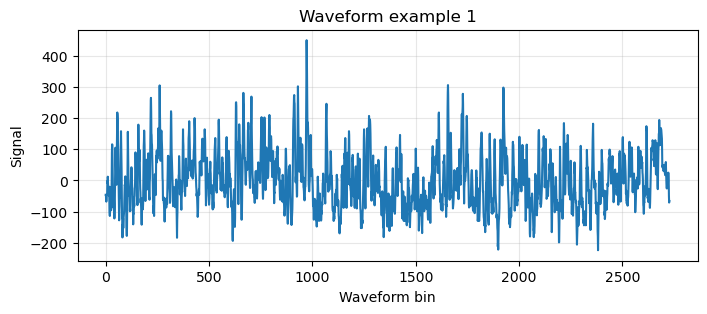

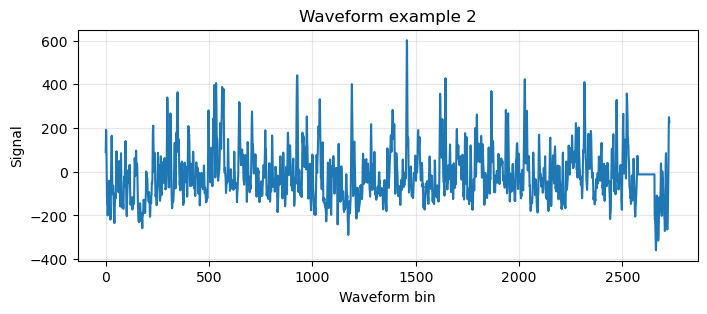

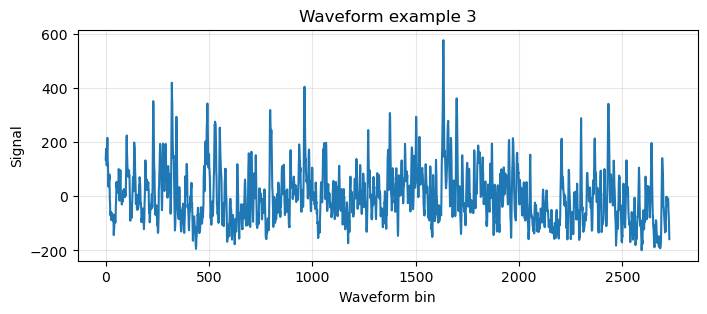

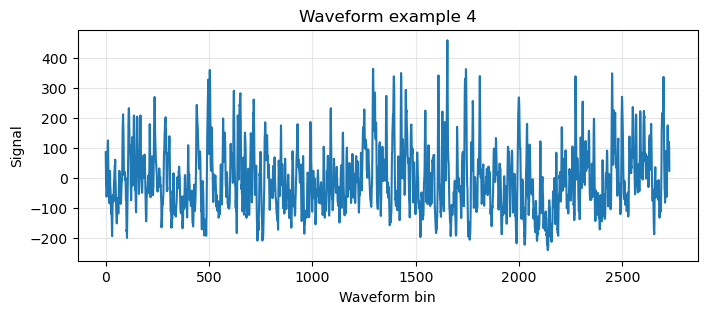

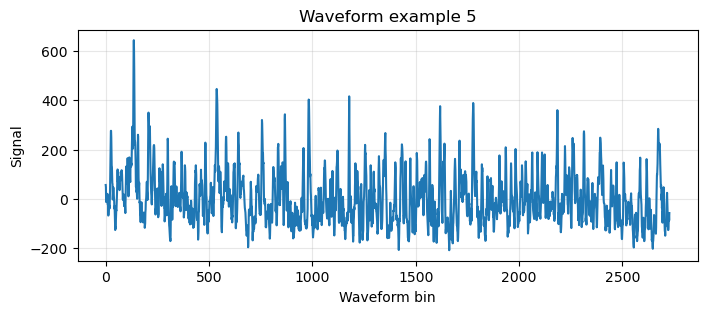

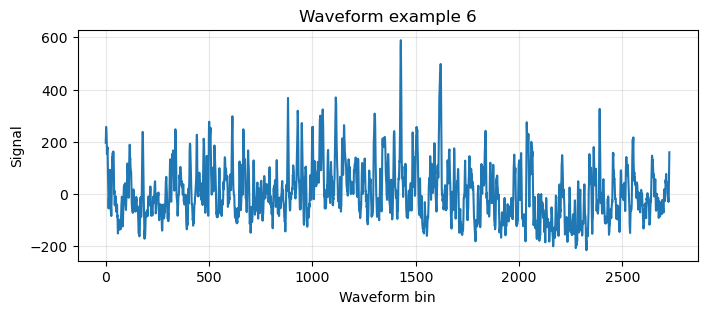

In [13]:
def load_waveform_examples(h5_path, rx_path, n_examples=N_WAVEFORM_EXAMPLES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    with h5py.File(h5_path, "r") as f:
        ds = f[rx_path]
        shape = ds.shape
        if len(shape) == 0:
            return None, shape

        # Interpret last dimension as waveform bins when possible.
        if len(shape) == 1:
            # one waveform only
            arr = np.array(ds[()])
            return arr[None, :], shape

        # Flatten all leading dims into records; last dim is bins.
        n_records = int(np.prod(shape[:-1]))
        bins = shape[-1]
        idxs = rng.choice(n_records, size=min(n_examples, n_records), replace=False)
        examples = []
        for idx in idxs:
            multi_idx = np.unravel_index(idx, shape[:-1])
            examples.append(np.array(ds[multi_idx + (slice(None),)]))
        return np.stack(examples, axis=0), shape

for _, ss in shape_summary_df.iterrows():
    h5_file = ss["h5_file"]
    rx_path = ss.get("rx_waveform_path")
    if not rx_path:
        display(Markdown(f"### {Path(h5_file).name}: no `rx_waveform` dataset found"))
        continue

    examples, rx_shape = load_waveform_examples(h5_file, rx_path)
    display(Markdown(f"### {Path(h5_file).name}: `{rx_path}`, shape={rx_shape}"))

    if examples is None:
        print("No waveform examples loaded.")
        continue

    for i, y in enumerate(examples):
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(np.arange(len(y)), y)
        ax.set_xlabel("Waveform bin")
        ax.set_ylabel("Signal")
        ax.set_title(f"Waveform example {i+1}")
        ax.grid(alpha=0.3)
        plt.show()


## 10. Conservative georeferencing conclusion

The conclusion follows this logic:

- If per-bin or multi-return geolocation datasets are found, the file may contain geolocation for decomposed peaks; inspect those fields manually.
- If no such datasets are found, but complete platform geometry fields are present, strict georeferencing may still be possible in principle, but only after reconstructing the observation model.
- If neither per-bin/multi-return geolocation nor sufficient geometry fields are found, then waveform-decomposed non-reference peaks cannot be strictly georeferenced from this H5 alone.


In [14]:
def make_georef_conclusion_for_file(h5_file):
    pbg = per_bin_geo_candidates_df[per_bin_geo_candidates_df["h5_file"] == h5_file] if len(per_bin_geo_candidates_df) else pd.DataFrame()
    mrg = multi_return_geo_df[multi_return_geo_df["h5_file"] == h5_file] if len(multi_return_geo_df) else pd.DataFrame()
    geom = geometry_df[geometry_df["h5_file"] == h5_file] if len(geometry_df) else pd.DataFrame()
    canon = canonical_df[(canonical_df["h5_file"] == h5_file) & (canonical_df["path"].astype(str).str.len() > 0)]

    has_ref_geo = all(
        len(canon[canon["canonical_field"] == f]) > 0
        for f in ["refh_longitude", "refh_latitude", "refh"]
    )
    has_waveform = len(canon[canon["canonical_field"] == "rx_waveform"]) > 0

    geom_cats = set()
    if len(geom):
        for cats in geom["geometry_category"]:
            geom_cats.update(str(cats).split(","))

    # Conservative sufficient geometry categories. This is intentionally strict.
    has_possible_full_geometry = (
        ("platform_position" in geom_cats)
        and ("attitude" in geom_cats or "scan_look_angle" in geom_cats)
        and ("range_timing" in geom_cats or "calibration" in geom_cats)
    )

    if len(pbg) > 0 or len(mrg) > 0:
        status = "NEEDS_MANUAL_INSPECTION"
        conclusion = (
            "The H5 contains coordinate-like datasets with per-bin/per-waveform or multi-return/peak-like shapes/names. "
            "These fields may provide geolocation for decomposed peaks, but they must be manually inspected for exact semantics."
        )
    elif has_possible_full_geometry:
        status = "POSSIBLY_GEOREFERENCEABLE_WITH_MODEL"
        conclusion = (
            "No obvious per-bin or multi-return geolocation datasets were found, but platform/attitude/scan/range-like geometry fields exist. "
            "Strict georeferencing may be possible only by reconstructing the sensor observation model and validating calibration."
        )
    elif has_ref_geo and has_waveform:
        status = "REFERENCE_RETURN_ONLY_CONFIRMED_BY_SCHEMA_SCAN"
        conclusion = (
            "The H5 contains waveform data and one reference-return geolocation per pulse, but no evidence was found for per-bin or multi-return geolocation fields. "
            "Waveform-decomposed non-reference peaks should not be treated as strictly georeferenced points from this H5 alone."
        )
    elif has_ref_geo and not has_waveform:
        status = "REFERENCE_GEOLOCATION_FOUND_NO_WAVEFORM_MATCH"
        conclusion = (
            "Reference-return geolocation fields were found, but the expected waveform dataset was not clearly identified by name. "
            "Check dataset naming manually."
        )
    else:
        status = "INCONCLUSIVE"
        conclusion = (
            "The canonical reference-return geolocation and waveform fields were not both clearly identified. "
            "Manual schema inspection is required."
        )

    return {
        "h5_file": h5_file,
        "has_refh_longitude_latitude_height": has_ref_geo,
        "has_rx_waveform": has_waveform,
        "n_per_bin_geo_candidates": len(pbg),
        "n_multi_return_geo_candidates": len(mrg),
        "geometry_categories_found": ",".join(sorted(geom_cats)),
        "status": status,
        "conclusion": conclusion,
    }

conclusion_df = pd.DataFrame([make_georef_conclusion_for_file(str(p)) for p in h5_paths])
display(conclusion_df)

for _, r in conclusion_df.iterrows():
    display(Markdown(
        f"### Conclusion for `{Path(r['h5_file']).name}`\\n\\n"
        f"**Status:** `{r['status']}`\\n\\n"
        f"{r['conclusion']}"
    ))

if WRITE_CSV_OUTPUTS:
    conclusion_df.to_csv(OUTPUT_DIR / "h5_georef_conclusion.csv", index=False)
    canonical_df.to_csv(OUTPUT_DIR / "h5_canonical_fields.csv", index=False)
    per_bin_geo_candidates_df.to_csv(OUTPUT_DIR / "h5_per_bin_geo_candidates.csv", index=False)
    multi_return_geo_df.to_csv(OUTPUT_DIR / "h5_multi_return_geo_candidates.csv", index=False)
    geometry_df.to_csv(OUTPUT_DIR / "h5_geometry_candidates.csv", index=False)
    sample_summary_df.to_csv(OUTPUT_DIR / "h5_candidate_sample_summaries.csv", index=False)
    print(f"Wrote conclusion and candidate CSVs to: {OUTPUT_DIR.resolve()}")


,h5_file,has_refh_longitude_latitude_height,has_rx_waveform,n_per_bin_geo_candidates,n_multi_return_geo_candidates,geometry_categories_found,status,conclusion
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,True,True,2,0,"calibration,platform_position,range_timing,scan_look_angle",NEEDS_MANUAL_INSPECTION,The H5 contains coordinate-like datasets with per-bin/per-waveform or multi-return/peak-like shapes/names. These fields may provide geolocation for decompos...


### Conclusion for `casals_l1b_20241112T165718_001_02.h5`\n\n**Status:** `NEEDS_MANUAL_INSPECTION`\n\nThe H5 contains coordinate-like datasets with per-bin/per-waveform or multi-return/peak-like shapes/names. These fields may provide geolocation for decomposed peaks, but they must be manually inspected for exact semantics.

Wrote conclusion and candidate CSVs to: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\notebooks\casals_h5_schema_audit_outputs


## 11. How to interpret the result

The strongest evidence for **strict multi-return georeferencing** would be explicit datasets like:

- per-bin `longitude`, `latitude`, `height` arrays with waveform-bin dimensions;
- per-return `return_longitude`, `return_latitude`, `return_height`;
- geolocated peak/component arrays created by the L1B processor.

The strongest evidence against it is:

- `rx_waveform` has a bin dimension;
- `refh_longitude/refh_latitude/refh` have only one value per pulse;
- no coordinate-like arrays exist with waveform-bin or multi-return dimensions;
- no complete platform pose + beam/scan geometry + range calibration fields exist.

In that case, waveform decomposition is still useful for waveform-shape analysis, but decomposed non-reference peaks should not be exported as rigorously georeferenced LAS returns.
